In [ ]:
"""plot HST observation"""

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate

# Load FITS image
with fits.open('/home/linfel/linfel_data/hst_raw_JianyangLi/17293/stack_all.fits') as hdul:
    hst_data = hdul[0].data  # assuming image is in HDU 0
    header = hdul[0].header

# Extract metadata
orientat = header.get('ORIENTAT', 'N/A')
utc_mid = header.get('UTC-MID', 'N/A')

In [2]:
# clean data and logarithmic brightness scale
hst_data[hst_data < 0] = np.nan
log_hst = np.copy(hst_data)
mask = hst_data >= 0
log_hst[mask] = np.log10(hst_data[mask])

In [3]:
# coordinates are in 'Sun Body Center'
r_Didy_sys_bary = np.array([-1.252938965664409E+08, 1.736400744097055E+08, 1.017805938869286E+07])  # km
r_Hubble = np.array([-1.058142769367994E+08, 1.027338649631926E+08, -2.109203366145492E+03])        # km
target_distance = np.linalg.norm(r_Didy_sys_bary - r_Hubble)  # km

# Hubble pixel size
pixel_arcsec = 0.04
range_km = target_distance
pixel_fov = np.deg2rad(pixel_arcsec / 3600)  # pixel field of view in rad
pixel_km = 2 * range_km * np.tan(pixel_fov/2)

# Axes in km
ny, nx = log_hst.shape
x_km = np.arange(nx+1) * pixel_km
y_km = np.arange(ny+1) * pixel_km
x_km = x_km - x_km[-1]/2
y_km = y_km - y_km[-1]/2

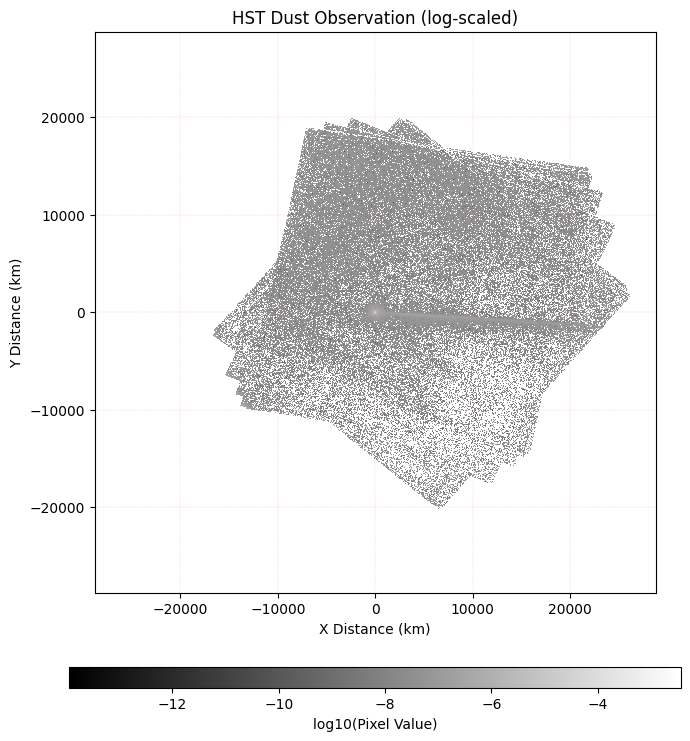

In [106]:
# Plot
X, Y = np.meshgrid(x_km, y_km)   # km

plt.figure(figsize=(8, 8))
pc = plt.pcolormesh(X, Y, log_hst, cmap='gray', shading='auto')

plt.xlabel('X Distance (km)')
plt.ylabel('Y Distance (km)')
plt.title('HST Dust Observation (log-scaled)')
plt.grid(True, linestyle='--', linewidth=0.1, color='red', alpha=0.7)

cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.8, aspect=30)  # pad adjusts spacing
cbar.set_label('log10(Pixel Value)')

# Set axis limits
plt.gca().set_aspect('equal', adjustable='box')
#plt.xlim(x_km[0], x_km[-1])
#plt.ylim(y_km[0], y_km[-1])

plt.tight_layout()
plt.savefig('hst_dust_observation_131.29.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [45]:
flat_index = np.nanargmax(log_hst)
i, j = np.unravel_index(flat_index, log_hst.shape)
print(f"Maximum at (i, j) = ({i}, {j}) with value = {log_hst[i, j]}")

Maximum at (i, j) = (2000, 2000) with value = -2.436722993850708


In [ ]:
"""align observation with simulation"""

In [4]:
import numpy as np
def rotate_coords(x, y, angle_deg, center=(0, 0)):
    """
    Rotate coordinates (x, y) by angle_deg around a given center.

    Parameters:
    - x, y: float or np.array of coordinates
    - angle_deg: rotation angle in degrees (positive = counterclockwise)
    - center: (x0, y0) tuple for rotation center (default is origin)

    Returns:
    - x_rot, y_rot: rotated coordinates
    """
    angle_rad = np.radians(angle_deg)

    x0, y0 = center

    x_rot = np.cos(angle_rad) * (x - x0) - np.sin(angle_rad) * (y - y0) + x0
    y_rot = np.sin(angle_rad) * (x - x0) + np.cos(angle_rad) * (y - y0) + y0

    return x_rot, y_rot

In [15]:
import numpy as np
import os, pickle
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames
import miepython as mie

# data path
data_rootdir = "/home/linfel/linfel_data/ejecta_exp_qpr/day131.29"
filenames = [os.path.join(data_rootdir, f"particle_{i:03d}_day131.29.pkl") for i in range(9, 22)]

# Ensure output directory exists for saving frames
output_dir = "/home/linfel/linfel_data/ejecta_exp_qpr/postprocess/plot_d131.29"
os.makedirs(output_dir, exist_ok=True)

# matrix convert vector from 'Sun Body Center' to 'Didymos System Barycenter'
SBC_rotate_DSB = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

# sky north vector and convert it to 'Didymos System Barycenter' frame
sky_north = np.array([0, 0, 1])
r_sky_north = np.dot(SBC_rotate_DSB, sky_north.T)

# optical parameters
m = 1.7 - 0.01j           # refractive index of particle
lambda0 = 500e-9  # wavelength in vacuum (m)

# pixel dimension parameters
nx = 4001  # number of bins in x axis
ny = 4001   # number of bins in y axis

xedges = x_km * 1e3
yedges = y_km * 1e3

In [16]:
inten_sets = []

for file in filenames:
    # Read particle data
    with open(file, 'rb') as f:
        data = pickle.load(f)
        p_t = data['p_t']
        radii_dust = data['radii_dust']
        day = data['day']

    # position vector
    r_sun = p_t[2, 1:4]    # [x, y, z] of the Sun
    r_earth = p_t[3, 1:4]  # [x, y, z] of the Earth   (as a proxy of HST)
    r_dust = p_t[4:, 1:4]  # [x, y, z] of all dust particles

    # calculate the two basis vectors of the projection plane
    l1 = np.cross(r_sky_north, r_earth)
    l2 = np.cross(r_earth, l1)
    l1 = l1 / np.linalg.norm(l1)
    l2 = l2 / np.linalg.norm(l2)

    # create an array to record coordinates of particles projected onto the plane
    p_projected = np.zeros((len(p_t),3), dtype=float)
    p_projected[:, 0] = p_t[:, 0]                  # copy the column of particle ID
    p_projected[:, 1] = np.dot(p_t[:, 1:4], l1)    # x coordinate
    p_projected[:, 2] = np.dot(p_t[:, 1:4], l2)    # y coordinate

    # rotate particles with an angle on the projected plane
    # This step is to align simulated tail with observation in a line
    p_projected[:, 1], p_projected[:, 2] = rotate_coords(p_projected[:, 1], p_projected[:, 2], 7.2)
    
    """2D density histogram"""
    hist_data = p_projected[4:]

    # Extract x and y projected coordinates
    x_proj = hist_data[:, 1]
    y_proj = hist_data[:, 2]

    # Mask out particles outside of range
    mask = (
        (x_proj >= xedges[0]) & (x_proj <= xedges[-1]) &
        (y_proj >= yedges[0]) & (y_proj <= yedges[-1])
    )
    x_filtered = x_proj[mask]
    y_filtered = y_proj[mask]

    # Create 2D histogram
    px_den, _, _ = np.histogram2d( # particle density of each pixel
        x_filtered,        # x coordinate
        y_filtered,        # y coordinate
        bins=[xedges, yedges],
        density=False  # Set True if you want normalized density
    )

    # set weight
    # W = 1e6
    # weight = 10 ** ((np.log10(radii_dust)+1) * np.log10(W) / (-3))    
    weight = 1

    # scattering intensity (assume scattering phase angle constant for all particles)
    qext, qsca, qback, g = mie.efficiencies(m, 2*radii_dust, lambda0)
    p_func = 1
    px_inten = qsca * (np.pi * radii_dust**2) * px_den * weight * p_func
    px_inten = px_inten.T

    inten_sets.append(px_inten)

In [17]:
# fit with intensity

sim_stack = np.stack(inten_sets, axis=-1)  # shape: (ny, nx, n_sizes)
#sim_stack[sim_stack <= 0] = np.nan

fit_input_X = sim_stack.reshape(-1, len(filenames))  # shape: (ny*nx, n_sizes)
fit_input_Y = hst_data.flatten()                      # shape: (ny*nx)

valid = ~np.isnan(fit_input_Y)   # use valid pixel values to fit

In [48]:
# data = fit_input_Y
# print(np.nanmin(data), np.nanmax(data))

In [18]:
# from numpy.linalg import lstsq
# weights, residuals, rank, s = lstsq(fit_input_X[valid], fit_input_Y[valid], rcond=None)

from scipy.optimize import nnls
weights, _ = nnls(fit_input_X[valid], fit_input_Y[valid])

In [19]:
print("Weights of different sizes: [" + "  ".join(f"{w:.2e}" for w in weights) + "]")

Weights of different sizes: [0.00e+00  1.31e-03  4.80e-04  2.45e-04  3.04e-05  2.31e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  3.26e-05  5.31e-05  7.88e-05]


In [20]:
I_fit = np.dot(fit_input_X, weights).reshape(np.shape(sim_stack)[:2])

In [21]:
# check the i,j index of the maximum pixel value
flat_index = np.argmax(I_fit)
i, j = np.unravel_index(flat_index, I_fit.shape)
print(f"Maximum at (i, j) = ({i}, {j}) with value = {I_fit[i, j]}")

Maximum at (i, j) = (2000, 2000) with value = 0.0037261760509723707


/tmp/ipykernel_1721592/1806950554.py:6: RuntimeWarning: divide by zero encountered in log10
  pc = plt.pcolormesh(X, Y, np.log10(I_fit), cmap='cividis', shading='auto')


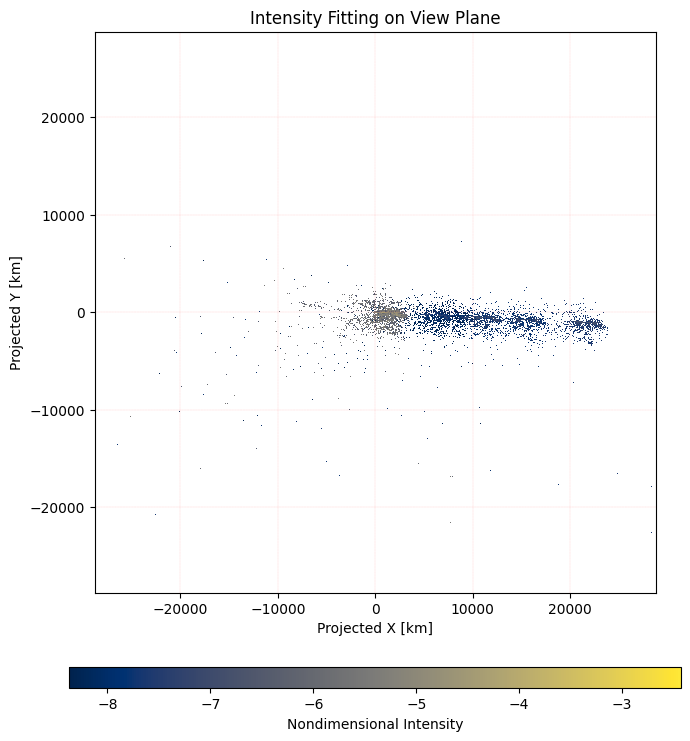

In [22]:
# Create meshgrid for bin edges
X, Y = np.meshgrid(xedges/1e3, yedges/1e3)   # km

# Plot using pcolor
plt.figure(figsize=(8, 8))
pc = plt.pcolormesh(X, Y, np.log10(I_fit), cmap='cividis', shading='auto')

plt.xlabel('Projected X [km]')
plt.ylabel('Projected Y [km]')
plt.title('Intensity Fitting on View Plane')
plt.grid(True, linestyle='--', linewidth=0.1, color='red', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(pc, orientation='horizontal', pad=0.1, shrink=0.8, aspect=30)
cbar.set_label('Nondimensional Intensity')

plt.tight_layout()
output_name = os.path.join(output_dir, "tail_fitting.png")
plt.savefig(output_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [12]:
radius = 10 ** np.linspace(-4,-1,21)
radius[8:]

array([0.00158489, 0.00223872, 0.00316228, 0.00446684, 0.00630957,
       0.00891251, 0.01258925, 0.01778279, 0.02511886, 0.03548134,
       0.05011872, 0.07079458, 0.1       ])

In [13]:
qpr = np.array([0.96572956, 0.96424726, 0.96316453, 0.96237575, 0.96180253,
       0.96138691, 0.9610862 , 0.96086906, 0.96071255, 0.96059993,
       0.96051901, 0.96046096, 0.96041936, 0.96038958, 0.9603683 ,
       0.9603531 , 0.96034225, 0.96033451, 0.960329  , 0.96032507,
       0.96032228])

In [14]:
np.vstack([radius[8:], qpr[8:], weights]).T

array([[1.58489319e-03, 9.60712550e-01, 0.00000000e+00],
       [2.23872114e-03, 9.60599930e-01, 7.33537161e-04],
       [3.16227766e-03, 9.60519010e-01, 2.68912688e-04],
       [4.46683592e-03, 9.60460960e-01, 1.37503115e-04],
       [6.30957344e-03, 9.60419360e-01, 1.70629869e-05],
       [8.91250938e-03, 9.60389580e-01, 1.29465087e-05],
       [1.25892541e-02, 9.60368300e-01, 0.00000000e+00],
       [1.77827941e-02, 9.60353100e-01, 0.00000000e+00],
       [2.51188643e-02, 9.60342250e-01, 0.00000000e+00],
       [3.54813389e-02, 9.60334510e-01, 0.00000000e+00],
       [5.01187234e-02, 9.60329000e-01, 1.82909695e-05],
       [7.07945784e-02, 9.60325070e-01, 2.97215158e-05],
       [1.00000000e-01, 9.60322280e-01, 4.41165815e-05]])